In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

jigsaw_agile_community_rules_path = kagglehub.competition_download('jigsaw-agile-community-rules')
gauripatil2299_deberta_v3_base_transformers_default_1_path = kagglehub.model_download('gauripatil2299/deberta-v3-base/Transformers/default/1')

print('Data source import complete.')


## 📦 Libraries & Config

In [8]:
!ls $gauripatil2299_deberta_v3_base_transformers_default_1_path

deberta-v3-base


In [3]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from tqdm import tqdm

# CONFIG

In [12]:
SEED = 42
NFOLDS = 5
MAX_LEN = 256
BATCH_SIZE = 16*4
EPOCHS = 10
MODEL_PATH = f"{gauripatil2299_deberta_v3_base_transformers_default_1_path}/deberta-v3-base"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
# Set seeds
torch.manual_seed(SEED)
np.random.seed(SEED)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 📁 Load Data

In [15]:
# Load and preprocess data
train_path = f"{jigsaw_agile_community_rules_path}/train.csv"
test_path = f"{jigsaw_agile_community_rules_path}/test.csv"
sample_sub_path = f"{jigsaw_agile_community_rules_path}/sample_submission.csv"

In [16]:
df = pd.read_csv(train_path)
df["text"] = df["rule"] + " [SEP] " + df["body"]
df["label"] = df["rule_violation"].astype(float)
# #use extra examples from train data
# dftr= pd.read_csv(train_path)
# dftr1,dftr2,dftr3,dftr4= dftr.copy(),dftr.copy(),dftr.copy(),dftr.copy()
# dftr1["text"] = dftr["positive_example_1"] + " [SEP] " + dftr["body"]
# dftr1["label"] = 1
# dftr2["text"] = dftr["positive_example_2"] + " [SEP] " + dftr["body"]
# dftr2["label"] = 1
# dftr3["text"] = dftr["negative_example_1"] + " [SEP] " + dftr["body"]
# dftr3["label"] = 0
# dftr4["text"] = dftr["negative_example_2"] + " [SEP] " + dftr["body"]
# dftr4["label"] = 0
# print(df.shape)
# df=pd.concat([df,dftr1,dftr2,dftr3,dftr4])
# print(df.shape,'After Concat')
# df.drop_duplicates
#implement test-time -training
# dft = pd.read_csv(test_path)
# dft["text"] = df["rule"] + " [SEP] " + df["body"]
# dft["label"] = df["rule_violation"].astype(float)

In [17]:
# Load tokenizer locally
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast = False)

## 📊 EDA Visualization

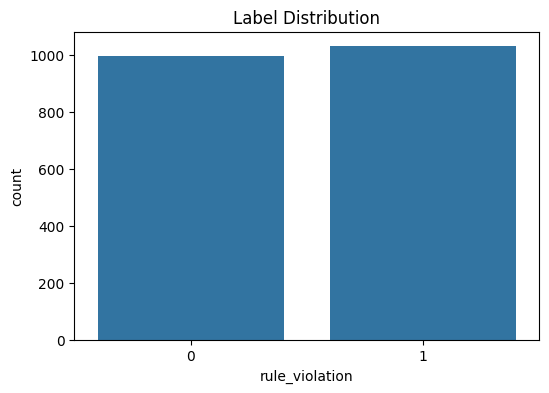

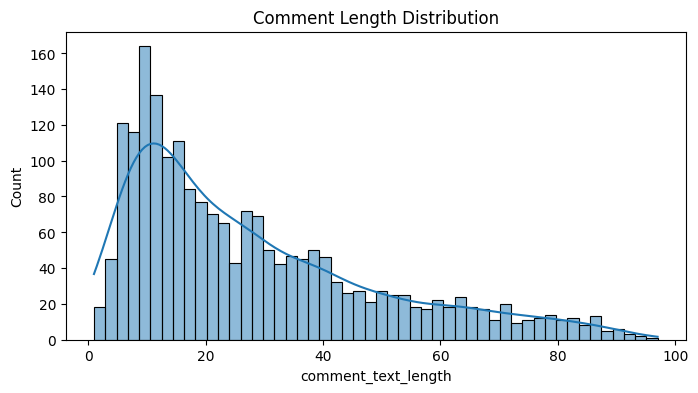

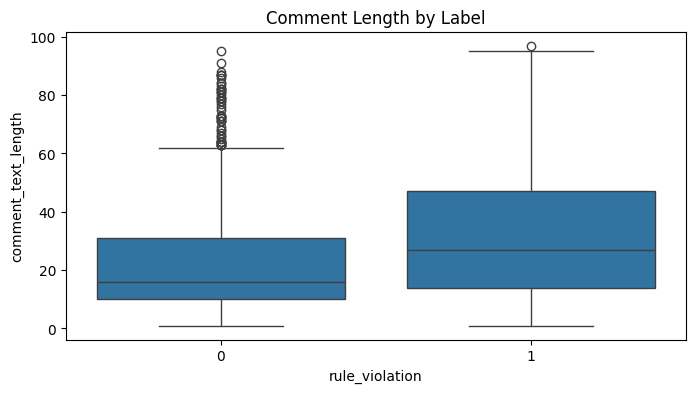

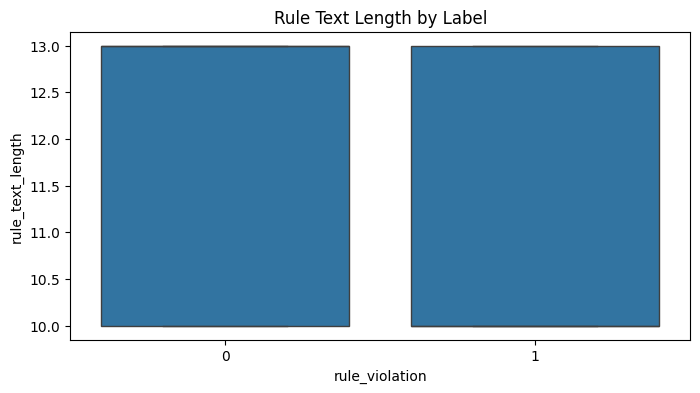

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='rule_violation', data=df)
plt.title('Label Distribution')
plt.show()

plt.figure(figsize=(8, 4))
df['rule_text_length'] = df['rule'].apply(lambda x: len(str(x).split()))
df['comment_text_length'] = df['body'].apply(lambda x: len(str(x).split()))
sns.histplot(df['comment_text_length'], bins=50, kde=True)
plt.title('Comment Length Distribution')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x='rule_violation', y='comment_text_length', data=df)
plt.title('Comment Length by Label')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x='rule_violation', y='rule_text_length', data=df)
plt.title('Rule Text Length by Label')
plt.show()

## 🔧 Dataset Class

In [19]:
print(df.head())
print(df.columns.tolist())

   row_id                                               body  \
0       0  Banks don't want you to know this! Click here ...   
1       1  SD Stream [ ENG Link 1] (http://www.sportsstre...   
2       2  Lol. Try appealing the ban and say you won't d...   
3       3  she will come your home open her legs with  an...   
4       4  code free tyrande --->>> [Imgur](http://i.imgu...   

                                                rule      subreddit  \
0  No Advertising: Spam, referral links, unsolici...     Futurology   
1  No Advertising: Spam, referral links, unsolici...  soccerstreams   
2  No legal advice: Do not offer or request legal...   pcmasterrace   
3  No Advertising: Spam, referral links, unsolici...            sex   
4  No Advertising: Spam, referral links, unsolici...    hearthstone   

                                  positive_example_1  \
0  If you could tell your younger self something ...   
1  [I wanna kiss you all over! Stunning!](http://...   
2  Don't break up wi

In [20]:
def add_data(dataframe):
    ret=[[],[]]
    for i in ['positive_example_1','positive_example_2','negative_example_1','negative_example_2']:
        tmp= (dataframe[i]+' [SEP] '+ dataframe['body']).tolist()
        tmp= list(set(tmp))
        ret[0]+= tmp
        ret[1]+= [1]*len(tmp) if 'positive' in i else [0]*len(tmp)
    return ret

In [21]:
class JigsawDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len,df=None,df_test=None):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        if df is not None:
            extras=add_data(df)
            self.texts+= extras[0]
            self.labels+= extras[1]
            print('Added additional data of size from train examples',len(extras[1]))
        if df_test is not None:
            extras=add_data(df_test)
            self.texts+= extras[0]
            self.labels+= extras[1]
            print('Added additional data of size from test examples',len(extras[1]))

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        enc = self.tokenizer(
            text, padding='max_length', truncation=True, max_length=self.max_len, return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

## 🧠 Model

In [22]:
class JigsawModel(nn.Module):
    def __init__(self, model_path):
        super().__init__()
        self.base = AutoModel.from_pretrained(model_path)
        self.drop = nn.Dropout(0.2)
        self.out = nn.Linear(self.base.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.base(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0]
        return self.out(self.drop(pooled)).squeeze(1)

## 🚂 Training Loop

In [23]:
def train_one_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    for batch in tqdm(loader):
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        logits = model(input_ids, mask)
        loss = nn.BCEWithLogitsLoss()(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [24]:
def validate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            logits = model(input_ids, mask)
            preds.extend(torch.sigmoid(logits).cpu().numpy())
            targets.extend(labels.cpu().numpy())
    auc = roc_auc_score(targets, preds)
    return auc, np.array(preds)

In [ ]:
all_preds = []
folds = StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=SEED)
for fold, (tr_idx, val_idx) in enumerate(folds.split(df, df["label"])):
    print(f"\n===== Fold {fold + 1} =====")
    df_test = pd.read_csv(test_path)
    train_ds = JigsawDataset(df.iloc[tr_idx]['text'].tolist(), df.iloc[tr_idx]['label'].tolist(), tokenizer, MAX_LEN,df=df,df_test=df_test)
    val_ds = JigsawDataset(df.iloc[val_idx]['text'].tolist(), df.iloc[val_idx]['label'].tolist(), tokenizer, MAX_LEN)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

    model = JigsawModel(MODEL_PATH).to(DEVICE)
    model = torch.nn.DataParallel(model)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, num_warmup_steps=len(train_loader), num_training_steps=len(train_loader) * EPOCHS
    )

    best_auc = 0
    for epoch in range(EPOCHS):
        print(f"Epoch {epoch+1}/{EPOCHS}")
        loss = train_one_epoch(model, train_loader, optimizer, scheduler)
        val_auc, val_preds = validate(model, val_loader)
        print(f"Loss: {loss:.4f}, Val AUC: {val_auc:.4f}")
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), f"model_fold{fold}.bin")

    all_preds.append(val_preds)


===== Fold 1 =====
Added additional data of size from train examples 8107
Added additional data of size from test examples 40
Epoch 1/10


 18%|█▊        | 28/153 [00:24<01:41,  1.23it/s]

## 🎯 Visualization

## 📄 Submission

In [ ]:
sample = pd.read_csv(sample_sub_path)
df_test = pd.read_csv(test_path)
df_test["text"] = df_test["rule"] + " [SEP] " + df_test["body"]

# ⭕ Load test predictions from saved model

In [ ]:
test_preds = []
for fold in range(NFOLDS):
    model = JigsawModel(MODEL_PATH).to(DEVICE)
    model.load_state_dict(torch.load(f"model_fold{fold}.bin", map_location=DEVICE))
    model.eval()

    test_ds = JigsawDataset(df_test['text'].tolist(), [0]*len(df_test), tokenizer, MAX_LEN)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

    fold_preds = []
    with torch.no_grad():
        for batch in test_loader:
            ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            logits = model(ids, mask)
            fold_preds.extend(torch.sigmoid(logits).cpu().numpy())
    test_preds.append(fold_preds)


In [ ]:
final_preds = np.mean(test_preds, axis=0)
sample["rule_violation"] = final_preds
sample.to_csv("submission.csv", index=False)
print("✅ Submission saved as submission.csv")

# ✅ Conclusion
### - Transformer-based solution (RoBERTa) with cross-validation
### - Visual analytics: label dist, length, attention
### - Ready for ensembling, pseudo-labeling, or threshold optimization